In [ ]:
!pip install pmdarima tensorflow scikit-learn matplotlib pandas numpy


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
from pmdarima import auto_arima
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving datasets_8494_11879_test_BdBKkAj.csv to datasets_8494_11879_test_BdBKkAj (2).csv
Saving train_aWnotuB.csv to train_aWnotuB (1).csv


In [ ]:
import os
os.listdir()


['.config',
 'train_aWnotuB.csv',
 'datasets_8494_11879_test_BdBKkAj (1).csv',
 'train_aWnotuB (1).csv',
 'datasets_8494_11879_test_BdBKkAj (2).csv',
 'datasets_8494_11879_test_BdBKkAj.csv',
 'sample_data']

In [ ]:
import pandas as pd

# Use the original ones (without numbers)
train = pd.read_csv('train_aWnotuB.csv')
test = pd.read_csv('datasets_8494_11879_test_BdBKkAj.csv')

print("✅ Training Data Shape:", train.shape)
print("✅ Test Data Shape:", test.shape)
train.head()


✅ Training Data Shape: (48120, 4)
✅ Test Data Shape: (11808, 3)


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [ ]:
train = pd.read_csv('train_aWnotuB.csv')
test = pd.read_csv('datasets_8494_11879_test_BdBKkAj.csv')

print("✅ Training Data Shape:", train.shape)
print("✅ Test Data Shape:", test.shape)
train.head()

✅ Training Data Shape: (48120, 4)
✅ Test Data Shape: (11808, 3)


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [ ]:
print(train.info())
print(train.describe())

train = train.fillna(method='ffill')
test = test.fillna(method='ffill')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None
           Junction      Vehicles            ID
count  48120.000000  48120.000000  4.812000e+04
mean       2.180549     22.791334  2.016330e+10
std        0.966955     20.750063  5.944854e+06
min        1.000000      1.000000  2.015110e+10
25%        1.000000      9.000000  2.016042e+10
50%        2.000000     15.000000  2.016093e+10
75%        3.000000     29.000000  2.017023e+10
max        4.000000    180.000000  2.017063e+10


/tmp/ipython-input-2277005586.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train = train.fillna(method='ffill')
/tmp/ipython-input-2277005586.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test = test.fillna(method='ffill')


In [ ]:
train.columns


Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')

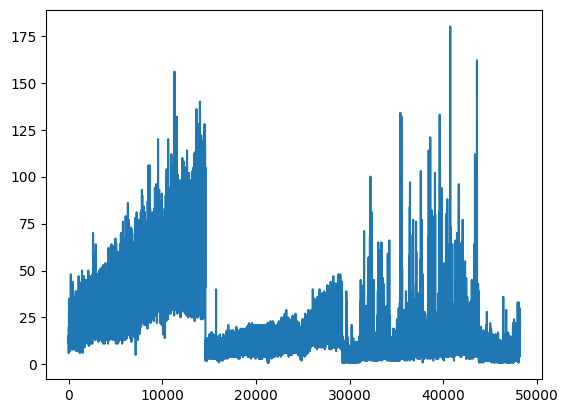

In [ ]:
plt.plot(train['Vehicles'], label='Traffic Volume')

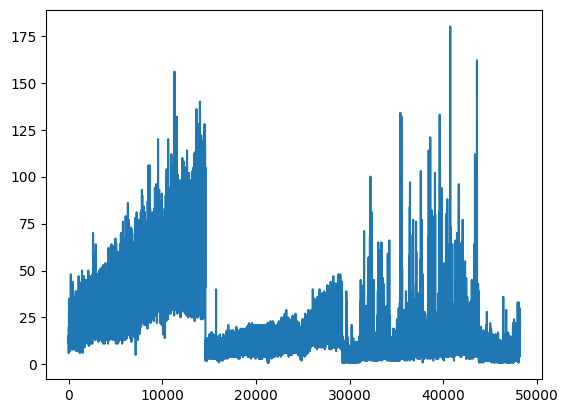

In [ ]:
plt.plot(train['Vehicles'], label='Traffic Volume')

In [ ]:
train['traffic_volume'] = train['Vehicles']

In [ ]:
train.head()


,DateTime,Junction,Vehicles,ID,traffic_volume
0,2015-11-01 00:00:00,1,15,20151101001,15
1,2015-11-01 01:00:00,1,13,20151101011,13
2,2015-11-01 02:00:00,1,10,20151101021,10
3,2015-11-01 03:00:00,1,7,20151101031,7
4,2015-11-01 04:00:00,1,9,20151101041,9


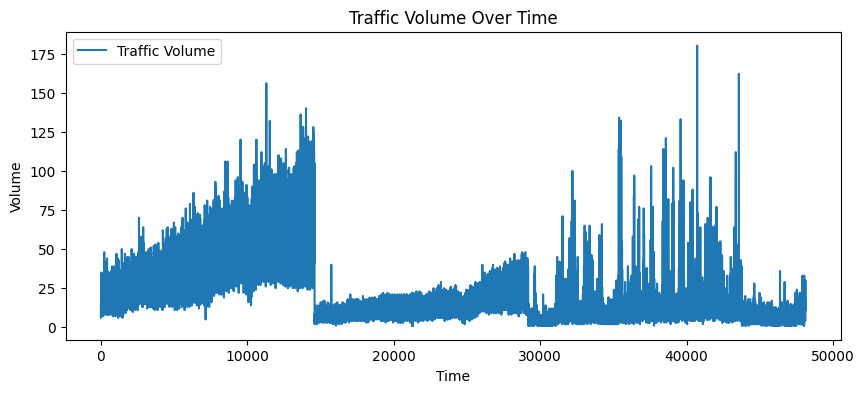

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(train['Vehicles'], label='Traffic Volume')
plt.title("Traffic Volume Over Time")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.legend()
plt.show()

In [ ]:
arima_model = auto_arima(train['traffic_volume'], seasonal=False, stepwise=True, trace=False)
arima_model.summary()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                48120
Model:               SARIMAX(5, 1, 2)   Log Likelihood             -142878.090
Date:                Sun, 09 Nov 2025   AIC                         285772.180
Time:                        18:18:29   BIC                         285842.432
Sample:                             0   HQIC                        285794.225
                              - 48120                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7798      0.003    621.078      0.000       1.774       1.785
ar.L2         -0.8180      0.004   -210.927      0.000      -0.826      -0.810
ar.L3          0.0035      0.005      0.641      0.522      -0.007       0.014
ar.L4         -0.0163      0.006     -2.516      0.012      -0.029      -0.004
ar.L5         -0.0265      0.004     -7.465      0.000      -0.033      -0.020
ma.L1         -1.8739      0.003   -714.952      0.000      -1.879      -1.869
ma.L2          0.9037      0.003    352.543      0.000       0.899       0.909
sigma2        22.2101      0.029    769.136      0.000      22.153      22.267
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           5274867.59
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.95   Skew:                             2.30
Prob(H) (two-sided):                  0.00   Kurtosis:                        54.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


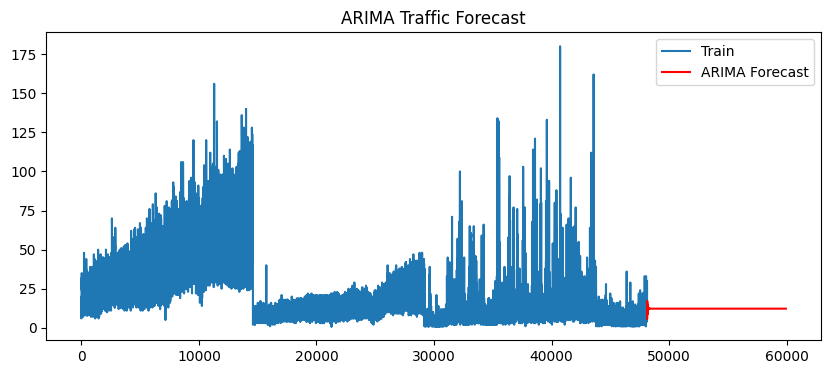

In [ ]:
n_periods = len(test)
arima_pred = arima_model.predict(n_periods=n_periods)

plt.figure(figsize=(10,4))
plt.plot(train['traffic_volume'], label='Train')
plt.plot(range(len(train), len(train)+len(test)), arima_pred, label='ARIMA Forecast', color='red')
plt.title("ARIMA Traffic Forecast")
plt.legend()
plt.show()


In [ ]:
series = train['traffic_volume'].values
n_input = 10
n_features = 1

generator = TimeseriesGenerator(series, series, length=n_input, batch_size=32)


In [ ]:
model = Sequential([
    LSTM(64, activation='relu', input_shape=(n_input, n_features)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(generator, epochs=20)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1504/1504 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 76.0147
Epoch 2/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 28.3372
Epoch 3/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 23.6079
Epoch 4/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 22.8842
Epoch 5/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 20.0446
Epoch 6/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 18.2428
Epoch 7/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 20.5332
Epoch 8/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 20.8101
Epoch 9/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 17.5351
Epoch 10/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 18.8030
Epoch 11/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 18.2692
Epoch 12/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 20.3629
Epoch 13/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 20.3700
Epoch 14/20
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 19.5250
Epoch 15/20
150

Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

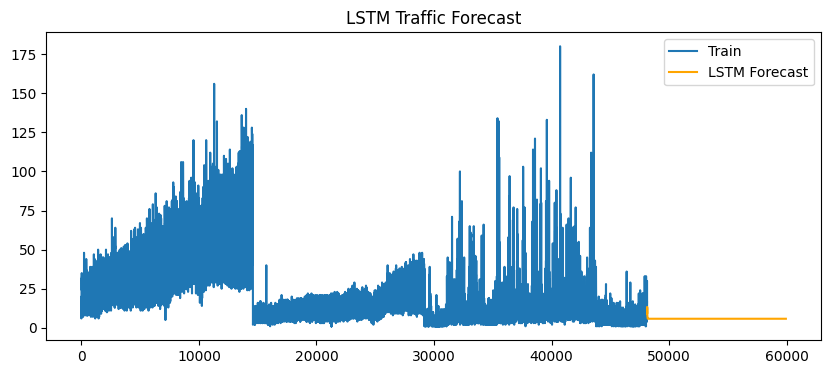

In [ ]:
pred_list = []
batch = series[-n_input:].reshape((1, n_input, n_features))

for i in range(len(test)):
    pred = model.predict(batch)[0]
    pred_list.append(pred)
    batch = np.append(batch[:,1:,:], [[pred]], axis=1)

lstm_pred = np.array(pred_list)

plt.figure(figsize=(10,4))
plt.plot(train['traffic_volume'], label='Train')
plt.plot(range(len(train), len(train)+len(test)), lstm_pred, label='LSTM Forecast', color='orange')
plt.title("LSTM Traffic Forecast")
plt.legend()
plt.show()


In [39]:
if 'traffic_volume' in test.columns:
    y_true = test['traffic_volume'].values
    mae_arima = mean_absolute_error(y_true, arima_pred)
    rmse_arima = sqrt(mean_squared_error(y_true, arima_pred))
    mae_lstm = mean_absolute_error(y_true, lstm_pred)
    rmse_lstm = sqrt(mean_squared_error(y_true, lstm_pred))

    print("📈 ARIMA MAE:", mae_arima, "RMSE:", rmse_arima)
    print("📈 LSTM MAE:", mae_lstm, "RMSE:", rmse_lstm)
else:
    print("⚠️ No actual traffic_volume column in test dataset to evaluate!")


⚠️ No actual traffic_volume column in test dataset to evaluate!


In [40]:
output = pd.DataFrame({
    'ARIMA_Predicted': arima_pred,
    'LSTM_Predicted': lstm_pred.flatten()
})
output.to_csv('Traffic_Forecast_Output.csv', index=False)
print("✅ Forecast saved as Traffic_Forecast_Output.csv")


✅ Forecast saved as Traffic_Forecast_Output.csv


In [41]:
import pandas as pd

output = pd.read_csv('Traffic_Forecast_Output.csv')
print(output.head())


   ARIMA_Predicted  LSTM_Predicted
0        10.724471       12.316624
1         9.242384       11.160830
2         7.886627       10.417504
3         6.685316        9.819168
4         5.936883        9.191045


In [42]:
from google.colab import files
files.download('Traffic_Forecast_Output.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>